<a href="https://colab.research.google.com/github/sophieangulo/NNs-for-tampa-restaurant-cleanliness/blob/main/Tampa_Hygiene_spaCy_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecting Restaurant Hygiene Risk with spaCy Features


# Import Our Data

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_dir = "/content/drive/MyDrive/ba510 data"

import pandas as pd
import numpy as np
import re

biz = pd.read_csv(base_dir + "/tampa_business_inspections.csv")
print(f"Business-level table: {biz.shape}")

reviews = pd.read_csv(
    base_dir + "/tampa_reviews_inspections.csv",
    usecols=["business_id", "review_text", "review_stars", "review_date"]
)
print(f"Reviews: {reviews.shape}")

# Keep the same text-cleaning idea as the main group notebook:
# remove URL noise, normalize whitespace, and cap very long text.
def clean_review_text(x, max_chars=4000):
    if pd.isna(x):
        return ""
    x = str(x)
    x = re.sub(r"http\S+|www\.\S+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x[:max_chars]

reviews["review_text_clean"] = reviews["review_text"].apply(clean_review_text)
reviews["review_date"] = pd.to_datetime(reviews["review_date"], errors="coerce")

reviews.head()


Business-level table: (2653, 95)
Reviews: (334342, 4)


In [ ]:
biz.head(3)

,business_id,yelp_name,yelp_address,yelp_city,yelp_postal_code,yelp_latitude,yelp_longitude,yelp_stars,yelp_review_count,yelp_categories,...,V_54,V_55,V_56,V_57,V_58,match_score,INSP_NO,VISIT_NO,LIC_ID,INSP_VST_ID
0,Ucl9Vo5lwrUmYbV8Dv8X5g,O'Briens Irish Pub,15435 N Dale Mabry Hwy,Tampa,33618,28.092360,-82.500588,4.0,108,"Bars, Pubs, Nightlife, Arts & Entertainment, I...",...,0,0,0,0,0,100.0,3578564,1,4421753,10756887
1,VVvUBlc_WIEb8obKGq39dA,Four Green Fields,"4100 George J Bean Pkwy, Airside E, Tampa Inte...",Tampa,33607,27.980399,-82.537787,4.5,39,"Irish Pub, Bars, Restaurants, Irish, Nightlife",...,0,0,0,0,0,100.0,3565659,1,6437715,10706039
2,XwoXi0M66RU6Gouq-DSDHw,G Peppers Grill & Tavern,8745 Gunn Hwy,Odessa,33556,28.092136,-82.578574,4.0,82,"Restaurants, Mexican, American (Traditional)",...,0,0,0,0,0,100.0,3578475,1,4318987,10756798


# Define Our Target Variable

The main group notebook defines the target as a high-priority violation indicator:

`label = 1` if the restaurant had at least one high-priority violation on its most recent FL DBPR inspection.

I use the same definition here so the preprocessing lines up with the group submission. Earlier versions of this notebook also considered punitive inspection dispositions, but for consistency with the final FusionNet notebook and slides, the submitted version uses `HIGH_VIOL >= 1`.


In [ ]:
# Match the target definition used in the main Tampa_Hygiene_Detection notebook.
# 1 = at least one high-priority violation
# 0 = no high-priority violation

biz["label"] = (biz["HIGH_VIOL"].fillna(0) >= 1).astype(int)

# Keep this alias so the rest of the notebook is easy to read.
biz["high_risk"] = biz["label"]

print("Label distribution:")
print(biz["label"].value_counts().sort_index())
print(f"\nPositive rate: {biz['label'].mean():.3f}")


Label distribution:
high_risk
0    1338
1    1315
Name: count, dtype: int64

Positive rate: 0.496


The positive label rate is close to balanced, so accuracy is still interpretable. I still report F1 and ROC-AUC because the goal is not only to be correct overall, but also to separate high-risk from low-risk restaurants and avoid missing too many true high-risk cases.


# Descriptive Statistics

Let's quickly look at the violation distribution and how reviews are distributed across restaurants.

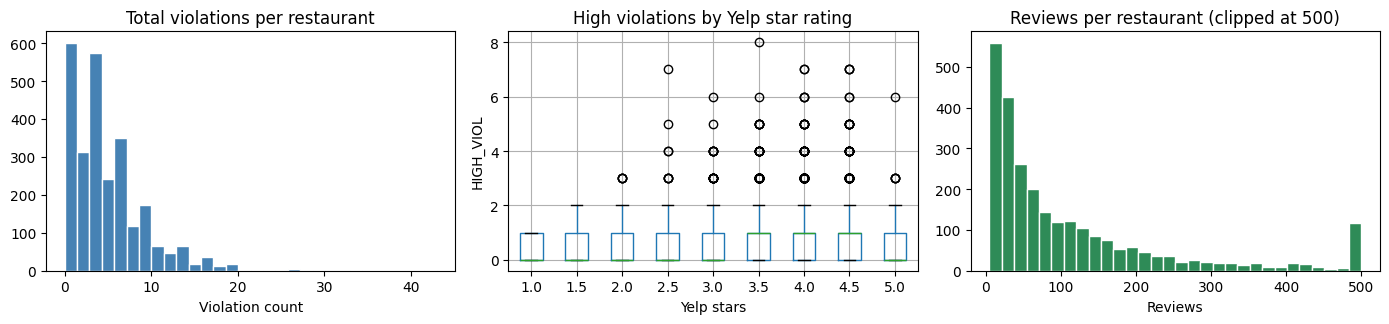

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# Total violations per restaurant
axes[0].hist(biz["VIOLATIONS"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Total violations per restaurant")
axes[0].set_xlabel("Violation count")

# High violations by Yelp star rating
biz.boxplot(column="HIGH_VIOL", by="yelp_stars", ax=axes[1])
axes[1].set_title("High violations by Yelp star rating")
axes[1].set_xlabel("Yelp stars"); axes[1].set_ylabel("HIGH_VIOL")
plt.suptitle("")

# Reviews per restaurant
reviews_per_biz = reviews.groupby("business_id").size()
axes[2].hist(reviews_per_biz.clip(upper=500), bins=30, color="seagreen", edgecolor="white")
axes[2].set_title("Reviews per restaurant (clipped at 500)")
axes[2].set_xlabel("Reviews")

plt.tight_layout()
plt.show()

# Train, Validation, and Test Splits

In [ ]:
from sklearn.model_selection import train_test_split

SEED = 42

biz_ids = biz["business_id"].values
labels = biz["label"].values

# First split: hold out 10% for test
ids_train_full, ids_test, y_train_full, y_test = train_test_split(
    biz_ids,
    labels,
    test_size=0.10,
    stratify=labels,
    random_state=SEED
)

# Second split: take 10% of the total data for validation
# Since train_full is 90% of the data, 0.1111 * 0.90 ≈ 0.10
ids_train, ids_val, y_train, y_val = train_test_split(
    ids_train_full,
    y_train_full,
    test_size=0.1111,
    stratify=y_train_full,
    random_state=SEED
)

print(f"Train: {len(ids_train)} restaurants ({y_train.mean():.3f} pos)")
print(f"Val:   {len(ids_val)} restaurants ({y_val.mean():.3f} pos)")
print(f"Test:  {len(ids_test)} restaurants ({y_test.mean():.3f} pos)")

Train: 2122 restaurants (0.496 pos)
Val:   265 restaurants (0.494 pos)
Test:  266 restaurants (0.496 pos)


# Install and Load spaCy

Install spaCy and download the medium English model `en_core_web_md`. We need the medium model (not small) because it includes 300-dimensional word vectors, which we can use for semantic embedding. The small model `en_core_web_sm` does not have word vectors, only linguistic features.

In [ ]:
!pip install --quiet spacy
!python -m spacy download en_core_web_md --quiet

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

# Load the medium model. There are 300-dim word vectors PLUS the linguistic pipeline
nlp = spacy.load("en_core_web_md")

# Verify vectors are loaded
print(f"spaCy version: {spacy.__version__}")
print(f"Vector dimension: {nlp.vocab.vectors_length}")
print(f"Pipeline components: {nlp.pipe_names}")

# A quick test, then embed a sample sentence
sample = nlp("the kitchen was filthy and there were roaches everywhere")
print(f"\nSample sentence vector shape: {sample.vector.shape}")
print(f"First 5 values: {sample.vector[:5]}")

spaCy version: 3.8.14
Vector dimension: 300
Pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']

Sample sentence vector shape: (300,)
First 5 values: [-0.7279633   0.10839222 -0.23040356 -0.03101644 -0.137381  ]


# Building the spaCy Linguistic Features

This section builds the spaCy linguistic features used in the presentation.

The features are:



`n_reviews`: number of reviews used for that restaurant
`avg_review_len': average review length in characters
`n_tokens`: total token count across selected reviews
`neg_rate`: share of tokens that are negations
`adj_rate`: share of tokens that are adjectives
`hyg_rate`: share of tokens with hygiene-related lemmas
`n_hyg_total`: raw count of hygiene-related lemmas

The main feature we care about is the `hyg_rate`. It gives the model a direct, interpretable variable for how often reviewers mention cleanliness or sanitation-related terms which works with our main objection. Lemmatization is also important as spaCy treats related word forms more consistently.


In [ ]:
hygiene_lemmas = {
    "dirty","clean","roach","cockroach","mold","moldy","bug","gross","filthy",
    "sanitary","unsanitary","fly","pest","nasty","disgusting","smell","smelly",
    "stink","stinky","hair","undercooked","raw","sticky","crumb","greasy",
    "gunk","grime","grimy","trash","garbage","rotten","spoil","spoiled",
    "contaminate","contaminated","sick","ill","poison","poisoning"
}

print(f"Number of hygiene lemmas in our vocabulary: {len(hygiene_lemmas)}")

Number of hygiene lemmas in our vocabulary: 39


In [ ]:
def extract_spacy_features(docs):
    # Takes a list of spaCy Doc objects and returns a dict of features
    if len(docs) == 0:
        return {"n_reviews": 0, "avg_review_len": 0, "n_tokens": 0,
                "neg_rate": 0, "adj_rate": 0, "hyg_rate": 0, "n_hyg_total": 0}

    n_tokens = n_neg = n_adj = n_hyg = 0
    total_chars = 0

    for doc in docs:
        total_chars += len(doc.text)
        for tok in doc:
            n_tokens += 1
            if tok.dep_ == "neg" or tok.lower_ in {"not","no","never","none"}:
                n_neg += 1
            if tok.pos_ == "ADJ":
                n_adj += 1
            if tok.lemma_.lower() in hygiene_lemmas:
                n_hyg += 1

    return {
        "n_reviews": len(docs),
        "avg_review_len": total_chars / len(docs),
        "n_tokens": n_tokens,
        "neg_rate": n_neg / max(n_tokens, 1),
        "adj_rate": n_adj / max(n_tokens, 1),
        "hyg_rate": n_hyg / max(n_tokens, 1),
        "n_hyg_total": n_hyg,
    }

# Building the Document Vectors

For fairness in terms of semantic representation we will average spaCy word vectors into one document vector per restaurant.

To match the main group notebook more closely, I use up to the 20 most recent reviews per restaurant. This keeps each restaurant on a comparable scale and prevents restaurants with thousands and thousands of reviews from dominating the feature-building step over those with very few reviews.


In [ ]:
def restaurant_doc_vector(docs):
    if len(docs) == 0:
        return np.zeros(300, dtype="float32")
    vecs = np.stack([doc.vector for doc in docs])
    return vecs.mean(axis=0).astype("float32")

For the extraction, with each restaurant, we will fetch its reviews, run them through spaCy in a batch, and then compute both the linguistic features and the document vector at the same time.

In [ ]:
max_reviews_per_biz = 20

print("Building review lookup table from cleaned review text...")

reviews_sorted = reviews.sort_values(["business_id", "review_date"], ascending=[True, False])

reviews_by_biz = (
    reviews_sorted
    .groupby("business_id")["review_text_clean"]
    .apply(lambda s: [x for x in s.head(max_reviews_per_biz).tolist() if str(x).strip() != ""])
    .to_dict()
)

print(f"Restaurants with at least one review: {len(reviews_by_biz)}")


Building review lookup table...
Restaurants with at least one review: 2653


In [ ]:
print("Running spaCy on selected reviews for each restaurant...")
t0 = time.time()

all_ids = list(ids_train) + list(ids_val) + list(ids_test)
spacy_feats = {}
doc_vecs = {}

for i, bid in enumerate(all_ids):
    texts = reviews_by_biz.get(bid, [])

    # Process selected reviews of this restaurant in one batch through spaCy.
    docs = list(nlp.pipe(texts, batch_size=32))

    spacy_feats[bid] = extract_spacy_features(docs)
    doc_vecs[bid] = restaurant_doc_vector(docs)

    if (i + 1) % 200 == 0:
        print(f"  {i + 1} / {len(all_ids)}  ({time.time() - t0:.0f}s)")

print(f"\nDone in {time.time() - t0:.0f}s")


Running spaCy on all restaurants (this is the main slow step)...
  200 / 2653  (84s)
  400 / 2653  (165s)
  600 / 2653  (247s)
  800 / 2653  (326s)
  1000 / 2653  (405s)
  1200 / 2653  (486s)
  1400 / 2653  (572s)
  1600 / 2653  (653s)
  1800 / 2653  (736s)
  2000 / 2653  (814s)
  2200 / 2653  (893s)
  2400 / 2653  (976s)
  2600 / 2653  (1058s)

Done in 1080s


Quick double check that we have all the features and vectors for every restaurant.

In [ ]:
print(f"Linguistic features extracted for {len(spacy_feats)} restaurants")
print(f"Doc vectors extracted for {len(doc_vecs)} restaurants")
print(f"\nSample linguistic features:")
sample_bid = ids_train[0]
print(f"  business_id={sample_bid}")
for k, v in spacy_feats[sample_bid].items():
    print(f"    {k}: {v:.4f}" if isinstance(v, float) else f"    {k}: {v}")

Linguistic features extracted for 2653 restaurants
Doc vectors extracted for 2653 restaurants

Sample linguistic features:
  business_id=U1UpMcEwV0YVdpAYCpO_qQ
    n_reviews: 7
    avg_review_len: 429.1429
    n_tokens: 654
    neg_rate: 0.0031
    adj_rate: 0.1009
    hyg_rate: 0.0015
    n_hyg_total: 1


# Just to check: Is `hyg_rate` Actually Predictive?

Before training the network, let's look at whether the hygiene-keyword density actually correlates with our label. If it doesn't, we are screwed.

In [ ]:
# Build a dataframe of spacy features for analysis
sf = pd.DataFrame.from_dict(spacy_feats, orient="index")
sf["high_risk"] = sf.index.map(dict(zip(biz["business_id"], biz["high_risk"])))

print("Mean spaCy features by risk class:")
print(sf.groupby("high_risk").mean().round(4))

Mean spaCy features by risk class:
           n_reviews  avg_review_len   n_tokens  neg_rate  adj_rate  hyg_rate  \
high_risk                                                                       
0            25.6824        467.4407  2626.8169    0.0152    0.0814    0.0023   
1            26.3924        460.8920  2664.9133    0.0147    0.0848    0.0022   

           n_hyg_total  
high_risk               
0               5.7227  
1               5.6395  


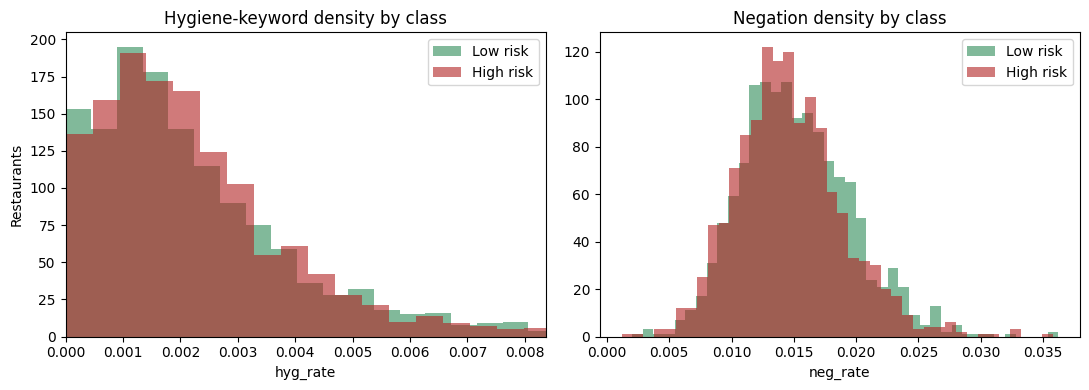

In [ ]:
# Plot hyg_rate distribution by class
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

low = sf[sf["high_risk"] == 0]["hyg_rate"]
high = sf[sf["high_risk"] == 1]["hyg_rate"]

axes[0].hist(low, bins=40, alpha=0.6, label="Low risk", color="seagreen")
axes[0].hist(high, bins=40, alpha=0.6, label="High risk", color="firebrick")
axes[0].set_xlabel("hyg_rate")
axes[0].set_ylabel("Restaurants")
axes[0].set_title("Hygiene-keyword density by class")
axes[0].set_xlim(0, sf["hyg_rate"].quantile(0.99))   # trim outliers for visibility
axes[0].legend()

# Same for negation rate
low_n = sf[sf["high_risk"] == 0]["neg_rate"]
high_n = sf[sf["high_risk"] == 1]["neg_rate"]
axes[1].hist(low_n, bins=40, alpha=0.6, label="Low risk", color="seagreen")
axes[1].hist(high_n, bins=40, alpha=0.6, label="High risk", color="firebrick")
axes[1].set_xlabel("neg_rate")
axes[1].set_title("Negation density by class")
axes[1].legend()

plt.tight_layout()
plt.show()

 hyg_rate shows a noticeable rightward shift for high-risk restaurants, which means higher values are more associated with high-risk outcomes. While there is still overlap between these two classes, this separation suggests that hyg_rate carries meaningful predictive signal.
 While the negation rate shows much heavier overlap between classes, indicating it is a weaker standalone feature. Overall, hyg_rate appears to be a useful feature, but not sufficient enough on its own to make predictions, which supports why we are combining it with other features in the model.

# Build the Feature Matrices

Now we combine the 7 spaCy linguistic features with the 300-dimensional spaCy document vector into one feature matrix.



In [ ]:
ling_cols = ["n_reviews","avg_review_len","n_tokens","neg_rate",
             "adj_rate","hyg_rate","n_hyg_total"]

def build_X(ids):
    ling = np.array([[spacy_feats[bid][c] for c in ling_cols] for bid in ids],
                    dtype="float32")
    docs = np.stack([doc_vecs[bid] for bid in ids])
    return np.column_stack([ling, docs])

X_tr = build_X(ids_train)
X_va = build_X(ids_val)
X_te = build_X(ids_test)

print(f"Train features: {X_tr.shape}  (7 linguistic + 300 doc-vector)")
print(f"Val features:   {X_va.shape}")
print(f"Test features:  {X_te.shape}")

Train features: (2122, 307)  (7 linguistic + 300 doc-vector)
Val features:   (265, 307)
Test features:  (266, 307)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the linguistic features (the doc vector dimensions are already on a
# stable scale because they come from pre-trained word embeddings)
scaler = StandardScaler().fit(X_tr[:, :7])
X_tr[:, :7] = scaler.transform(X_tr[:, :7])
X_va[:, :7] = scaler.transform(X_va[:, :7])
X_te[:, :7] = scaler.transform(X_te[:, :7])

# Define and Train the Model

A multi-layer perceptron with two hidden layers, batch normalization, and dropout. Sigmoid output for binary classification.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(X_tr.shape[1],))
x = layers.Dense(128, activation="relu")(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)
model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 307)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        39,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,257 (188.50 KB)

 Trainable params: 48,001 (187.50 KB)

 Non-trainable params: 256 (1.00 KB)

Save the best model based on validation accuracy.

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=base_dir + "/spacy_hygiene_model.keras",
        save_best_only=True,
        monitor="val_accuracy"),
    keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                   patience=10,
                                   restore_best_weights=True)
]

history = model.fit(
    X_tr, y_train,
    validation_data=(X_va, y_val),
    epochs=80,
    batch_size=64,
    callbacks=callbacks)

Epoch 1/80
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5099 - loss: 0.8198 - val_accuracy: 0.5660 - val_loss: 0.6837
Epoch 2/80
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5264 - loss: 0.7647 - val_accuracy: 0.5962 - val_loss: 0.6840
Epoch 3/80
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5391 - loss: 0.7418 - val_accuracy: 0.5849 - val_loss: 0.6803
Epoch 4/80
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5335 - loss: 0.7300 - val_accuracy: 0.5774 - val_loss: 0.6797
Epoch 5/80
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5500 - loss: 0.7095 - val_accuracy: 0.5660 - val_loss: 0.6821
Epoch 6/80
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5537 - loss: 0.7075 - val_accuracy: 0.5509 - val_loss: 0.6803
Epoch 7/80
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5363 - loss: 0.7095 - val_accuracy: 0.5132 - val_loss: 0.6842
Epoch 8/80
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5339 - loss: 0.6960 - val_accuracy: 0.5660 - val_loss

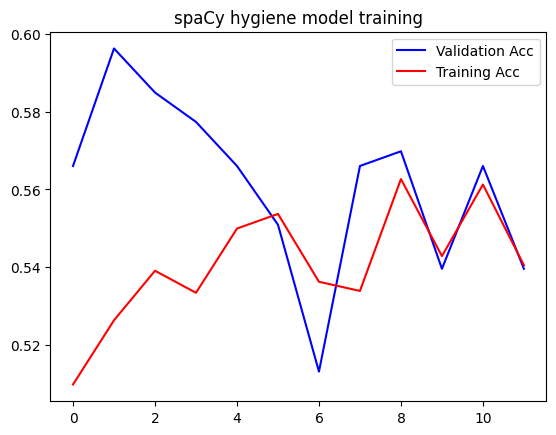

In [ ]:
plt.plot(history.history['val_accuracy'], c="b")
plt.plot(history.history['accuracy'], c="r")
plt.legend(['Validation Acc', 'Training Acc'])
plt.title("spaCy hygiene model training")
plt.show()

# Evaluate on the Test Set



In [ ]:
best_model = keras.models.load_model(base_dir + "/spacy_hygiene_model.keras")

test_loss, test_acc = best_model.evaluate(X_te, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.3f}")

p_te = best_model.predict(X_te, verbose=0).ravel()

Test accuracy: 0.523


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

yhat = (p_te >= 0.5).astype(int)
print(f"Accuracy:  {accuracy_score(y_test, yhat):.3f}")
print(f"Precision: {precision_score(y_test, yhat):.3f}")
print(f"Recall:    {recall_score(y_test, yhat):.3f}")
print(f"F1:        {f1_score(y_test, yhat):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, p_te):.3f}")

print("\nClassification report:")
print(classification_report(y_test, yhat, target_names=["Low risk","High risk"]))

Accuracy:  0.523
Precision: 0.514
Recall:    0.720
F1:        0.599
ROC-AUC:   0.537

Classification report:
              precision    recall  f1-score   support

    Low risk       0.54      0.33      0.41       134
   High risk       0.51      0.72      0.60       132

    accuracy                           0.52       266
   macro avg       0.53      0.52      0.50       266
weighted avg       0.53      0.52      0.50       266



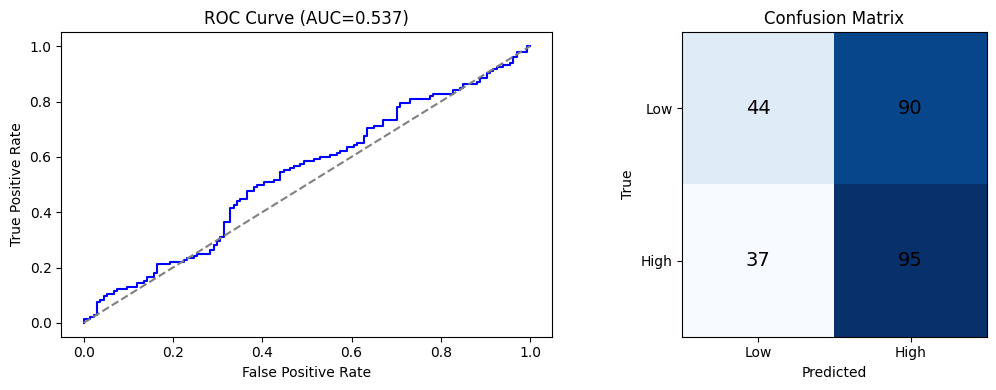

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, p_te)
axes[0].plot(fpr, tpr, c="b")
axes[0].plot([0,1],[0,1], "--", c="gray")
axes[0].set_title(f"ROC Curve (AUC={roc_auc_score(y_test, p_te):.3f})")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")

# Confusion matrix
cm = confusion_matrix(y_test, yhat)
axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(["Low","High"]); axes[1].set_yticklabels(["Low","High"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i,j], ha="center", va="center",
                     color="black", fontsize=14)

plt.tight_layout()
plt.show()

# Inspecting What the Model Learned

In [ ]:
# Pull review text for test restaurants for inspection
test_results = pd.DataFrame({
    "business_id": ids_test,
    "true_label": y_test,
    "predicted_proba": p_te
})

# Top 5 most-confident high-risk predictions
print("=" * 70)
print("TOP 5 PREDICTED HIGH-RISK RESTAURANTS")
print("=" * 70)
top_high = test_results.sort_values("predicted_proba", ascending=False).head(5)
for _, row in top_high.iterrows():
    name = biz[biz["business_id"] == row["business_id"]]["yelp_name"].values[0]
    sample_review = reviews[reviews["business_id"] == row["business_id"]]["review_text"].iloc[0][:300]
    print(f"\n{name}  |  pred={row['predicted_proba']:.3f}  |  true={row['true_label']}")
    print(f"  Sample review: {sample_review}...")

TOP 5 PREDICTED HIGH-RISK RESTAURANTS

Gaby's Family Restaurant  |  pred=0.656  |  true=1
  Sample review: Gaby's is a great place to pop in and grab a bite to eat. The service is always good and the waitresses are quick and efficient. I have never had an issue with anything I have ordered there; it is always exactly as I have ordered....

Yummy Garden  |  pred=0.645  |  true=1
  Sample review: Very nice and classy and reasonable Chinese restaurant. I took some pictures for you to see. I had the complimentary crispy noodles and sweet sauce. Wonton  soup was my choice and it was perfect. I had the lunch special Pepper Steak. Nice big strips of steak and onions and green bell peppers and oth...

Golden Wok  |  pred=0.641  |  true=0
  Sample review: Great service. Nice little place to grab takeout. Should be on your regular rounds. :)...

Taco Rey  |  pred=0.630  |  true=0
  Sample review: Me encanta hacen los tacos en la parrila frente uno. El servicio no es tan bueno las meseras son un 

In [ ]:
print("=" * 70)
print("TOP 5 PREDICTED LOW-RISK RESTAURANTS")
print("=" * 70)
top_low = test_results.sort_values("predicted_proba").head(5)
for _, row in top_low.iterrows():
    name = biz[biz["business_id"] == row["business_id"]]["yelp_name"].values[0]
    sample_review = reviews[reviews["business_id"] == row["business_id"]]["review_text"].iloc[0][:300]
    print(f"\n{name}  |  pred={row['predicted_proba']:.3f}  |  true={row['true_label']}")
    print(f"  Sample review: {sample_review}...")

TOP 5 PREDICTED LOW-RISK RESTAURANTS

Domino's Pizza  |  pred=0.426  |  true=0
  Sample review: Incredibly disappointed with this dominos.

The first two times I came here were flawless. Today I ordered carryout online at 2:41, I got to the dominos at 2:55 expecting to wait a couple minutes. According to the dominos tracker my pizza was put in the oven at 2:43, which was strange because the em...

McDonald's  |  pred=0.432  |  true=1
  Sample review: Food here is always great but they do often get stuff wrong. I ordered a McDouble with extra pickles and a McChicken. I got home and noticed they gave me 2 McChickens, one loaded with pickles. Needless to say I think I'll be adding pickles to my McChickens from now on. Good screw up, guys!...

Burger King  |  pred=0.433  |  true=1
  Sample review: The owner/manager is downright disrespectful.

Let's be honest folks - many of us question how most BK's are even still in business. This is one of them, and I don't really know of any with a bus